
Buscando mejores hiperparámetros...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Mejores parámetros: {'classifier__max_depth': 12, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 200}

── Random Forest (Test Set) ──
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      1593
           1       0.62      0.61      0.62       407

    accuracy                           0.84      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.84      0.84      0.84      2000

CV Accuracy : 0.8458 ± 0.0083
CV F1       : 0.8450 ± 0.0091
CV AUC-ROC  : 0.8588 ± 0.0100


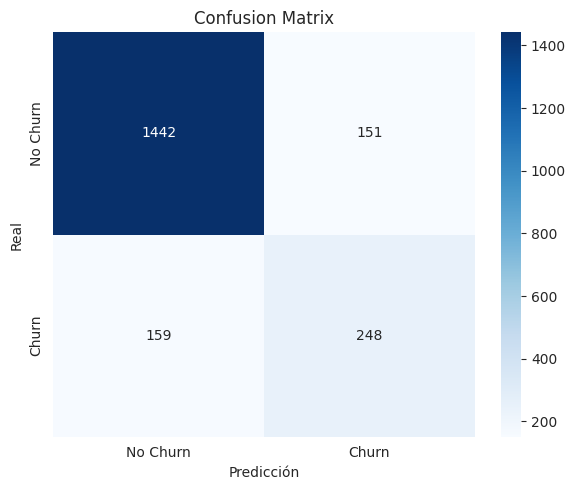

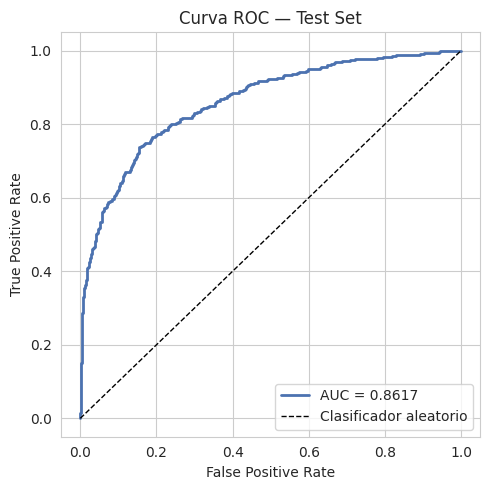


--- 7.1 Importancia global de características ---


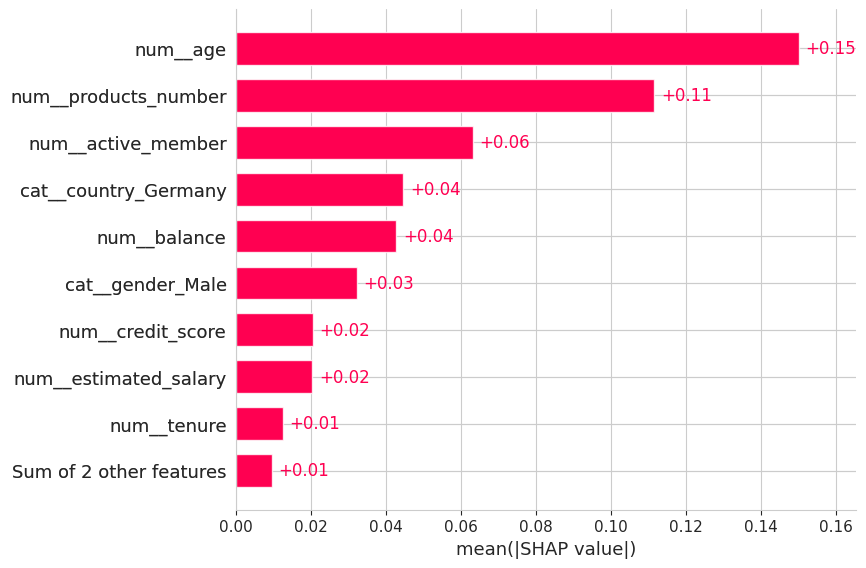


--- 7.2 Distribución y dirección de efectos (beeswarm) ---


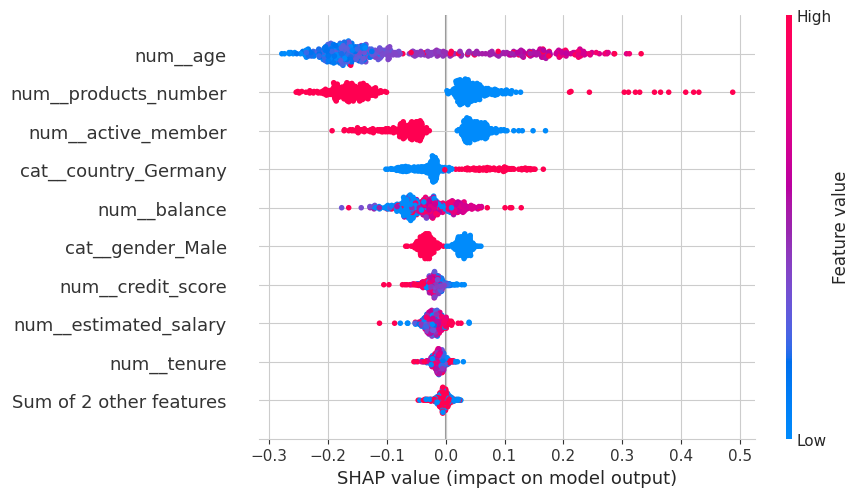


--- 7.3 Explicación del primer churn (waterfall) ---


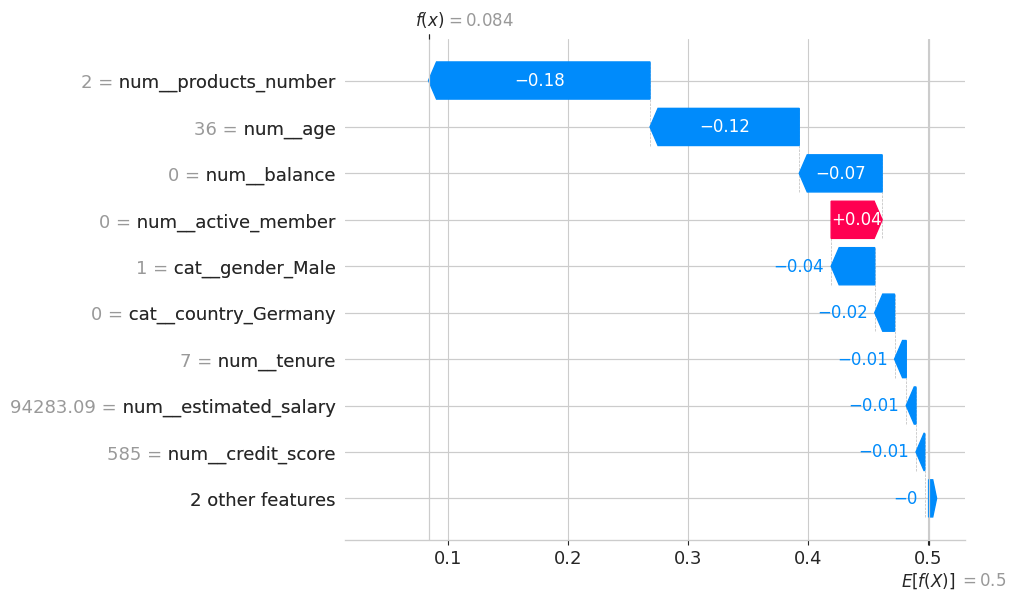


--- 7.4 Heatmap de efectos en todo el subconjunto ---


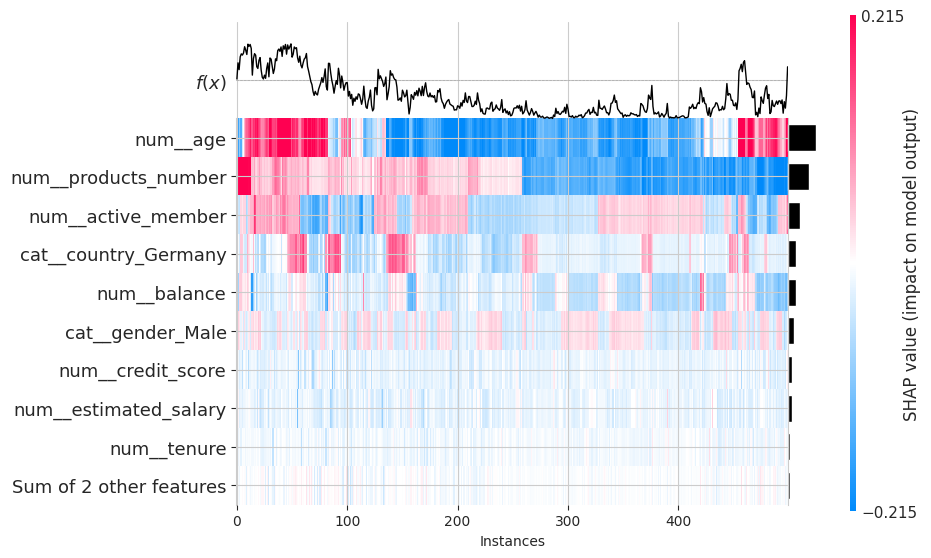

<Axes: xlabel='Instances'>

In [2]:
import os
import shap
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, auc, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)
random.seed(42)

df = pd.read_csv("Bank Customer Churn Prediction.csv")
df = df.drop(columns=["customer_id"], errors="ignore") # Elimina las columnas que no es útil para la predicción

# Separamos los datos
X = df.drop("churn", axis=1)
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # Dividimos los datos 80% para entrenar y el 20% para prueba

# Elegimos qué columnas son texto (país, género) y cuáles son números
cat_cols = ["gender", "country"]
num_cols = [col for col in X.columns if col not in cat_cols]

numeric_transformer = SimpleImputer(strategy="median") # Rellena valores faltantes con la mediana

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), # Si falta text añadimos el mas comun
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)) # Convertimos el texto a números (0 y 1) para que el modelo lo entienda
])

# Limpias las columnas
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

# Creamos el modelo
pipeline_base = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1))
])

print("\nBuscando mejores hiperparámetros...")


# Crea varios modelos con estos paramentros y selecciona el mejor
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [5, 12, None],
    "classifier__min_samples_split": [2, 5, 10]
}

# GridSearchCV se encargar de crear los modelos
modelo = GridSearchCV(
    pipeline_base,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

modelo.fit(X_train, y_train)
print("Mejores parámetros:", modelo.best_params_)

mejor_modelo = modelo.best_estimator_ # Selecciona el mejor modelo

# Probamos el modelo con los datos de prueba
pred = mejor_modelo.predict(X_test)
print("\n── Random Forest (Test Set) ──")
print(classification_report(y_test, pred))

# Validación cruzada con 5 folds para medir estabilidad del mode
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc = cross_val_score(mejor_modelo, X_train, y_train, cv=cv, scoring="accuracy")
f1 = cross_val_score(mejor_modelo, X_train, y_train, cv=cv, scoring="f1_weighted")
auc_cv = cross_val_score(mejor_modelo, X_train, y_train, cv=cv, scoring="roc_auc")
print(f"CV Accuracy : {acc.mean():.4f} ± {acc.std():.4f}")
print(f"CV F1       : {f1.mean():.4f} ± {f1.std():.4f}")
print(f"CV AUC-ROC  : {auc_cv.mean():.4f} ± {auc_cv.std():.4f}")


# Grafica Confusion Matrix, Nos muestra claramente cuántos aciertos hubo y en qué se confundió el modelo
cm = confusion_matrix(y_test, pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

# Grafica Curva Roc Muestra qué tan bueno es el modelo distinguiendo entre clases
proba_scores = mejor_modelo.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba_scores)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color="#4C72B0", lw=2, label=f"AUC = {roc_auc:.4f}")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Clasificador aleatorio")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Curva ROC — Test Set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()
# Cerramos los gráficos anteriores para no mezclarlos con los de SHAP
plt.close("all")

# Graficas con Shap Nos explica detalldamente como funciona el modelo
X_sample = X_test[:500].copy()

# Transformar datos usando el preprocesador del pipeline
preprocesador = mejor_modelo.named_steps["preprocessor"]
X_sample_transformed = preprocesador.transform(X_sample)

# Obtener nombres de las columnas
feature_names = preprocesador.get_feature_names_out()
X_sample_df = pd.DataFrame(X_sample_transformed, columns=feature_names)

# Extraer el Random Forest
modelo_rf = mejor_modelo.named_steps["classifier"]

# Calcular SHAP
explainer = shap.TreeExplainer(modelo_rf)
shap_values = explainer(X_sample_df)

# SHAP de Scikit-Learn RandomForest devuelve valores para ambas clases. Extraemos la clase 1 (Churn)
shap_values_class1 = shap_values[..., 1]

print("\n--- 7.1 Importancia global de características ---")
shap.plots.bar(shap_values_class1, max_display=10)

print("\n--- 7.2 Distribución y dirección de efectos (beeswarm) ---")
shap.plots.beeswarm(shap_values_class1, max_display=10)

print("\n--- 7.3 Explicación del primer churn (waterfall) ---")
shap.plots.waterfall(shap_values_class1[0], max_display=10)

print("\n--- 7.4 Heatmap de efectos en todo el subconjunto ---")
shap.plots.heatmap(shap_values_class1)